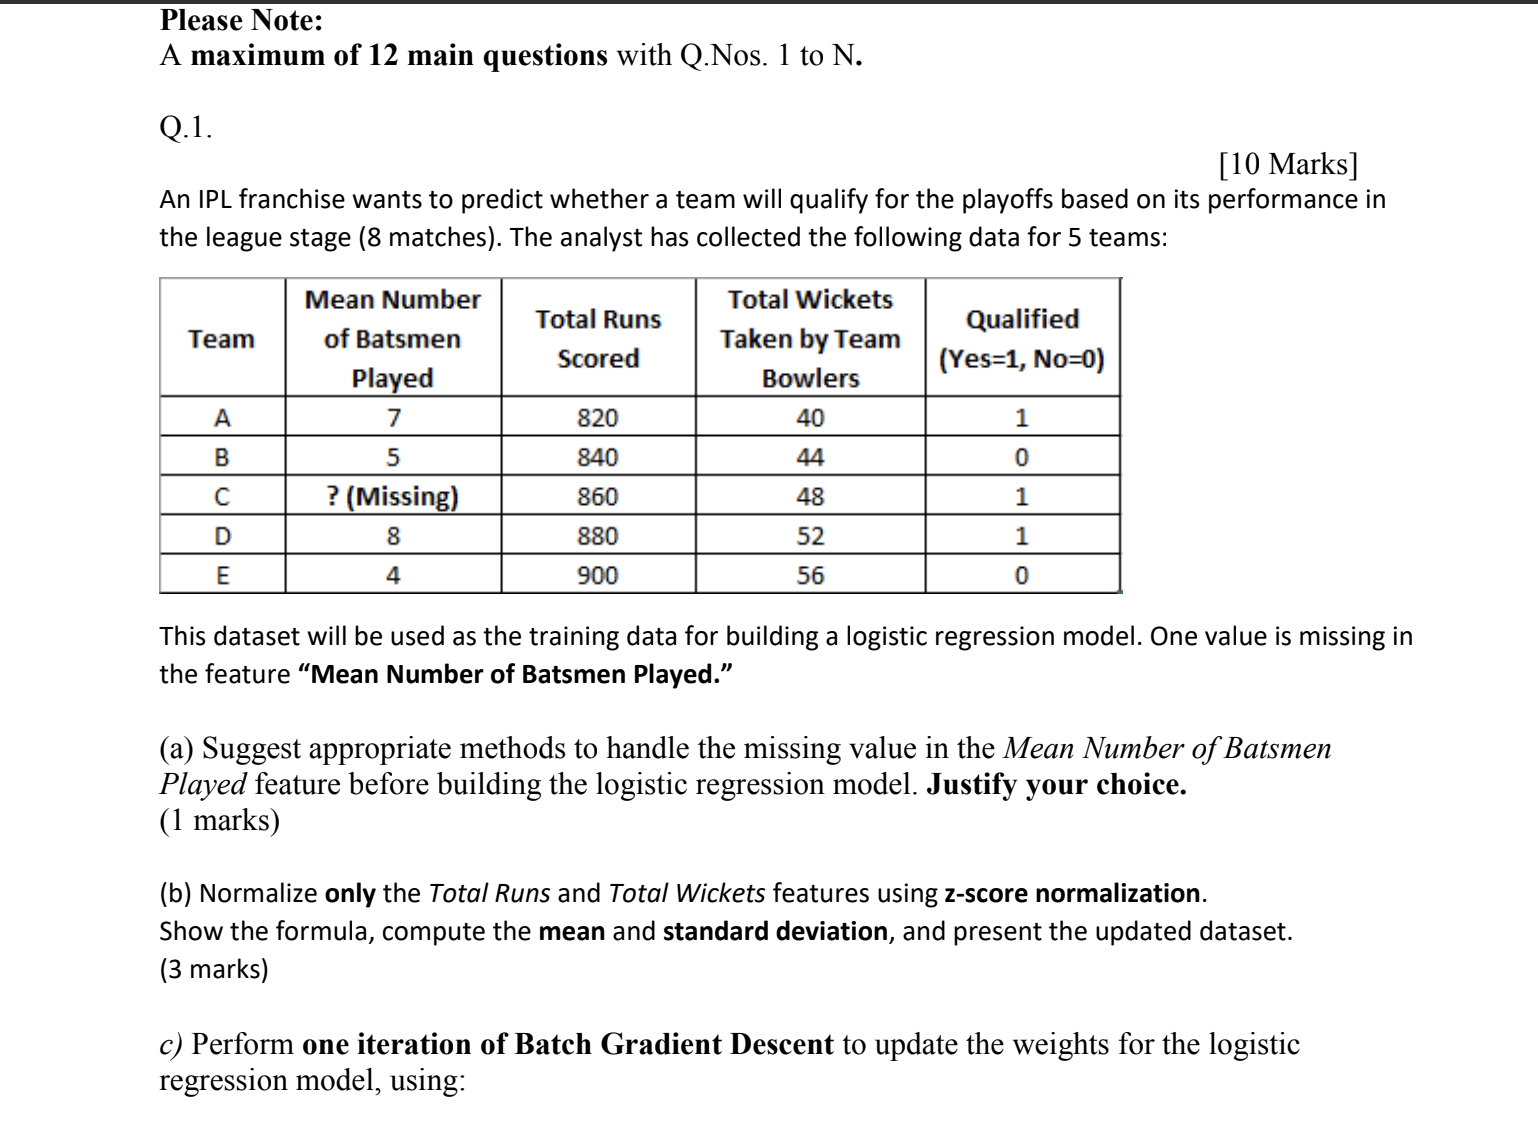

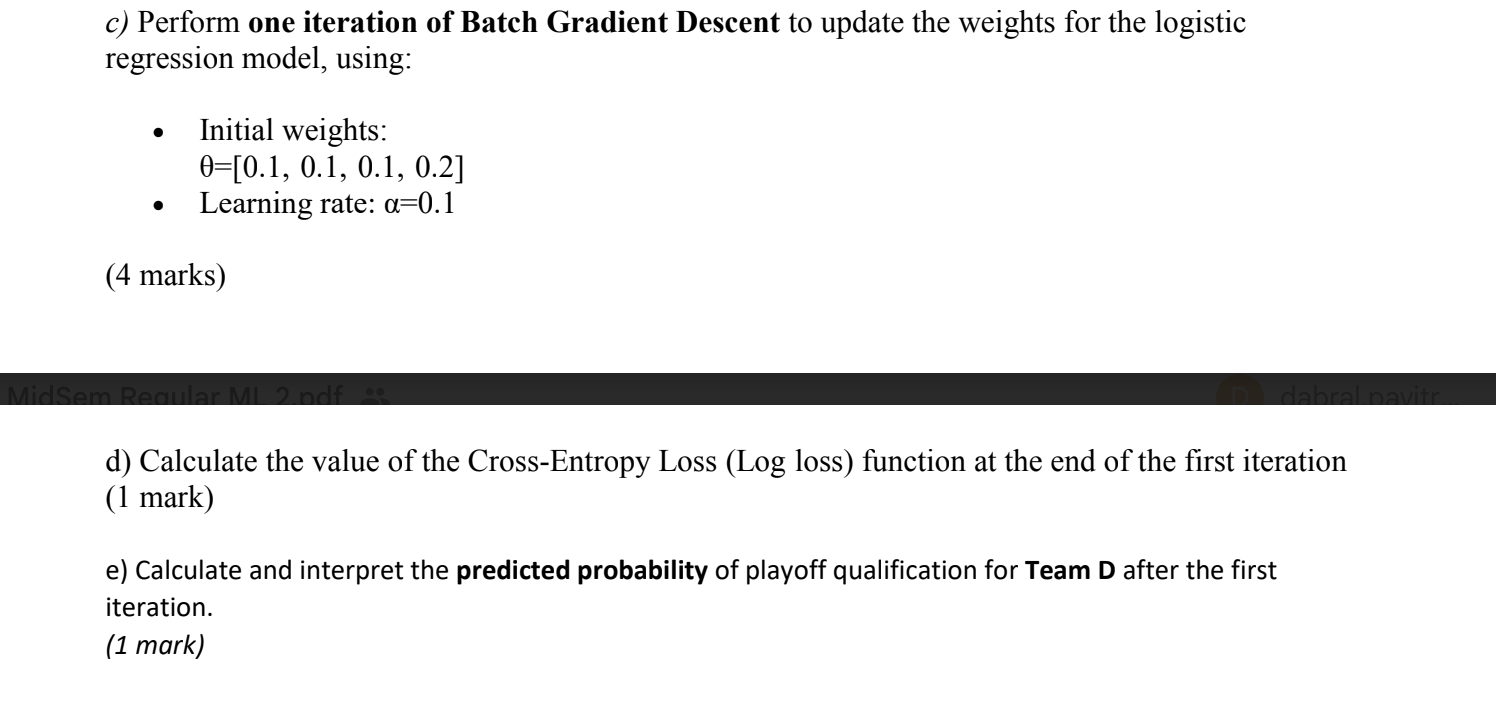

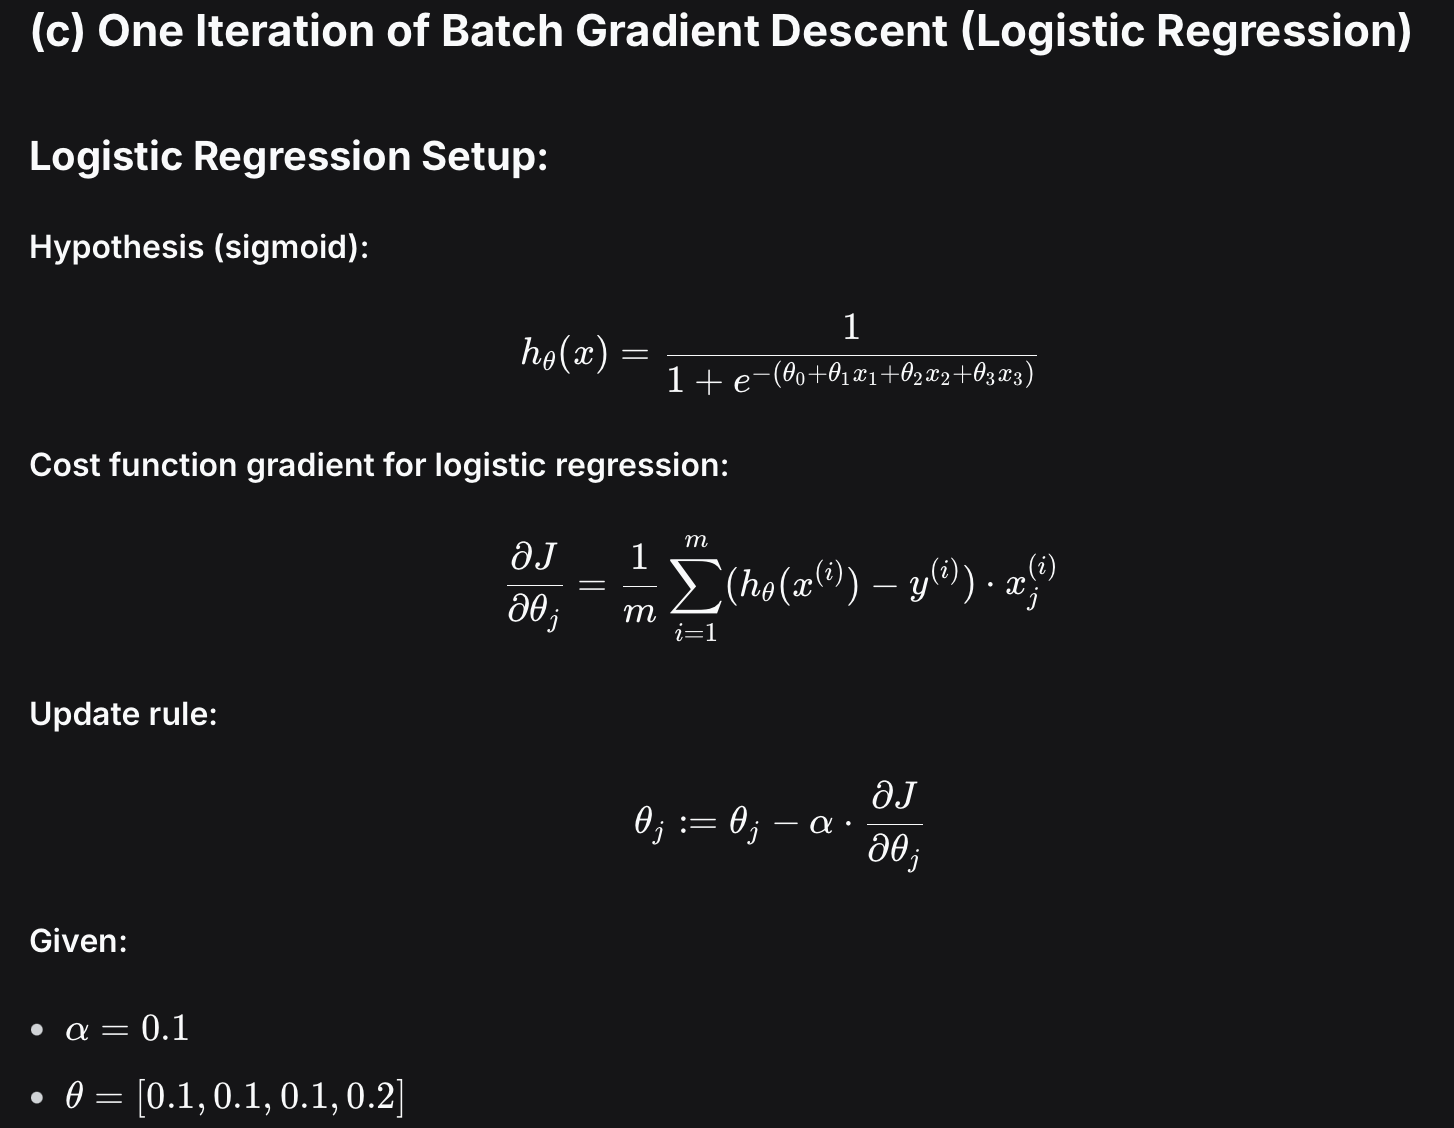

Here is the **complete step-by-step solution** to the IPL playoff prediction problem. I will address each part in sequence.

---

## (a) Handling the Missing Value in "Mean Number of Batsmen Played" (1 mark)

**Missing value:** Team C has `?` in "Mean Number of Batsmen Played".

### Suggested Method: **Mean Imputation**

- Compute the **mean** of the available values for that feature.
- Available values: 7 (A), 5 (B), 8 (D), 4 (E)
- Mean = \( \frac{7+5+8+4}{4} = \frac{24}{4} = 6 \)

**Fill missing value for Team C with 6.**

### Justification:
- Since we only have **5 samples**, dropping the row would lose valuable data.
- Mean imputation is simple, preserves sample size, and does not introduce extreme bias.
- It is safe because the feature is roughly continuous and no strong outlier is present.

**Updated dataset:**

| Team | Mean Batsmen | Total Runs | Total Wickets | Qualified |
|------|--------------|------------|---------------|-----------|
| A    | 7            | 820        | 40            | 1         |
| B    | 5            | 840        | 44            | 0         |
| C    | **6**        | 860        | 48            | 1         |
| D    | 8            | 880        | 52            | 1         |
| E    | 4            | 900        | 56            | 0         |

---

## (b) Z‑Score Normalization for Total Runs and Total Wickets (3 marks)

### Formula:
\[
z = \frac{x - \mu}{\sigma}
\]
Where:
- \( \mu \) = mean of the feature
- \( \sigma \) = standard deviation of the feature

---

### Step 1: For **Total Runs**

**Data:** 820, 840, 860, 880, 900

| Calculation | Result |
|-------------|--------|
| Sum | \( 820+840+860+880+900 = 4300 \) |
| Mean (\( \mu \)) | \( 4300 / 5 = 860 \) |
| Deviations | \( -40, -20, 0, 20, 40 \) |
| Squared deviations | \( 1600, 400, 0, 400, 1600 \) |
| Sum of squares | \( 1600+400+0+400+1600 = 4000 \) |
| Variance | \( 4000 / 5 = 800 \) |
| Std Dev (\( \sigma \)) | \( \sqrt{800} = 28.2843 \) |

**Normalized values:**
- A: \( (820-860)/28.2843 = -40/28.2843 = -1.4142 \)
- B: \( (840-860)/28.2843 = -20/28.2843 = -0.7071 \)
- C: \( (860-860)/28.2843 = 0 \)
- D: \( (880-860)/28.2843 = 20/28.2843 = 0.7071 \)
- E: \( (900-860)/28.2843 = 40/28.2843 = 1.4142 \)

---

### Step 2: For **Total Wickets**

**Data:** 40, 44, 48, 52, 56

| Calculation | Result |
|-------------|--------|
| Sum | \( 40+44+48+52+56 = 240 \) |
| Mean (\( \mu \)) | \( 240 / 5 = 48 \) |
| Deviations | \( -8, -4, 0, 4, 8 \) |
| Squared deviations | \( 64, 16, 0, 16, 64 \) |
| Sum of squares | \( 64+16+0+16+64 = 160 \) |
| Variance | \( 160 / 5 = 32 \) |
| Std Dev (\( \sigma \)) | \( \sqrt{32} = 5.6569 \) |

**Normalized values:**
- A: \( (40-48)/5.6569 = -8/5.6569 = -1.4142 \)
- B: \( (44-48)/5.6569 = -4/5.6569 = -0.7071 \)
- C: \( (48-48)/5.6569 = 0 \)
- D: \( (52-48)/5.6569 = 4/5.6569 = 0.7071 \)
- E: \( (56-48)/5.6569 = 8/5.6569 = 1.4142 \)

---

### Updated Dataset After Normalization

| Team | Mean Batsmen | Total Runs (Norm) | Total Wickets (Norm) | Qualified |
|------|--------------|-------------------|----------------------|-----------|
| A    | 7            | -1.4142           | -1.4142              | 1         |
| B    | 5            | -0.7071           | -0.7071              | 0         |
| C    | 6            | 0                 | 0                    | 1         |
| D    | 8            | 0.7071            | 0.7071               | 1         |
| E    | 4            | 1.4142            | 1.4142               | 0         |

---

## (c) One Iteration of Batch Gradient Descent (Logistic Regression)

### Logistic Regression Setup:

**Hypothesis (sigmoid):**
\[
h_\theta(x) = \frac{1}{1 + e^{-(\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_3)}}
\]

**Cost function gradient for logistic regression:**
\[
\frac{\partial J}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}
\]

**Update rule:**
\[
\theta_j := \theta_j - \alpha \cdot \frac{\partial J}{\partial \theta_j}
\]

**Given:**
- \( \alpha = 0.1 \)
- \( \theta = [0.1, 0.1, 0.1, 0.2] \)
- Features: \( x_1 \) = Mean Batsmen, \( x_2 \) = Norm Runs, \( x_3 \) = Norm Wickets
- Add bias term: \( x_0 = 1 \) for all samples.

---

### Data Matrix (with bias):

| Team | \( x_0 \) | \( x_1 \) (Batsmen) | \( x_2 \) (Runs Norm) | \( x_3 \) (Wickets Norm) | \( y \) |
|------|-----------|---------------------|-----------------------|--------------------------|---------|
| A    | 1         | 7                   | -1.4142               | -1.4142                  | 1       |
| B    | 1         | 5                   | -0.7071               | -0.7071                  | 0       |
| C    | 1         | 6                   | 0                     | 0                        | 1       |
| D    | 1         | 8                   | 0.7071                | 0.7071                   | 1       |
| E    | 1         | 4                   | 1.4142                | 1.4142                   | 0       |

---

### Step 1: Compute Linear Combinations \( z^{(i)} = \theta^T x^{(i)} \)

Using \( \theta = [0.1, 0.1, 0.1, 0.2] \):

**Team A:**  
\( z = 0.1(1) + 0.1(7) + 0.1(-1.4142) + 0.2(-1.4142) \)  
\( = 0.1 + 0.7 - 0.1414 - 0.2828 = 0.3758 \)

**Team B:**  
\( z = 0.1(1) + 0.1(5) + 0.1(-0.7071) + 0.2(-0.7071) \)  
\( = 0.1 + 0.5 - 0.0707 - 0.1414 = 0.3879 \)

**Team C:**  
\( z = 0.1(1) + 0.1(6) + 0.1(0) + 0.2(0) \)  
\( = 0.1 + 0.6 = 0.7 \)

**Team D:**  
\( z = 0.1(1) + 0.1(8) + 0.1(0.7071) + 0.2(0.7071) \)  
\( = 0.1 + 0.8 + 0.0707 + 0.1414 = 1.1121 \)

**Team E:**  
\( z = 0.1(1) + 0.1(4) + 0.1(1.4142) + 0.2(1.4142) \)  
\( = 0.1 + 0.4 + 0.1414 + 0.2828 = 0.9242 \)

---

### Step 2: Compute Sigmoid Predictions \( h = \sigma(z) = 1/(1+e^{-z}) \)

| Team | \( z \) | \( e^{-z} \) | \( h = 1/(1+e^{-z}) \) |
|------|---------|--------------|------------------------|
| A    | 0.3758  | 0.6866       | 0.5927                 |
| B    | 0.3879  | 0.6786       | 0.5957                 |
| C    | 0.7     | 0.4966       | 0.6682                 |
| D    | 1.1121  | 0.3288       | 0.7526                 |
| E    | 0.9242  | 0.3968       | 0.7159                 |

---

### Step 3: Compute Errors \( (h - y) \)

| Team | \( h \) | \( y \) | \( h - y \) |
|------|---------|---------|-------------|
| A    | 0.5927  | 1       | -0.4073     |
| B    | 0.5957  | 0       | 0.5957      |
| C    | 0.6682  | 1       | -0.3318     |
| D    | 0.7526  | 1       | -0.2474     |
| E    | 0.7159  | 0       | 0.7159      |

---

### Step 4: Compute Gradients \( \frac{\partial J}{\partial \theta_j} = \frac{1}{m} \sum (h-y) x_j \)

**For \( \theta_0 \) (bias, \( x_0 = 1 \)):**
\[
\frac{\partial J}{\partial \theta_0} = \frac{-0.4073 + 0.5957 - 0.3318 - 0.2474 + 0.7159}{5} = \frac{0.3251}{5} = 0.0650
\]

**For \( \theta_1 \) (Batsmen):**
\[
\frac{\partial J}{\partial \theta_1} = \frac{(-0.4073)(7) + (0.5957)(5) + (-0.3318)(6) + (-0.2474)(8) + (0.7159)(4)}{5}
\]
\[
= \frac{-2.8511 + 2.9785 - 1.9908 - 1.9792 + 2.8636}{5} = \frac{-0.9790}{5} = -0.1958
\]

**For \( \theta_2 \) (Runs Norm):**
\[
\frac{\partial J}{\partial \theta_2} = \frac{(-0.4073)(-1.4142) + (0.5957)(-0.7071) + (-0.3318)(0) + (-0.2474)(0.7071) + (0.7159)(1.4142)}{5}
\]
\[
= \frac{0.5760 - 0.4212 + 0 - 0.1749 + 1.0124}{5} = \frac{0.9923}{5} = 0.1985
\]

**For \( \theta_3 \) (Wickets Norm):**
\[
\frac{\partial J}{\partial \theta_3} = \frac{(-0.4073)(-1.4142) + (0.5957)(-0.7071) + (-0.3318)(0) + (-0.2474)(0.7071) + (0.7159)(1.4142)}{5}
\]
\[
= \frac{0.5760 - 0.4212 + 0 - 0.1749 + 1.0124}{5} = 0.1985
\]

---

### Step 5: Update Weights \( \theta_j := \theta_j - \alpha \cdot \text{gradient} \)

| Weight | Old \( \theta \) | Gradient | Update | New \( \theta \) |
|--------|-----------------|----------|--------|-----------------|
| \( \theta_0 \) | 0.1 | 0.0650 | \( 0.1 - 0.1(0.0650) = 0.1 - 0.0065 \) | **0.0935** |
| \( \theta_1 \) | 0.1 | -0.1958 | \( 0.1 - 0.1(-0.1958) = 0.1 + 0.01958 \) | **0.1196** |
| \( \theta_2 \) | 0.1 | 0.1985 | \( 0.1 - 0.1(0.1985) = 0.1 - 0.01985 \) | **0.0802** |
| \( \theta_3 \) | 0.2 | 0.1985 | \( 0.2 - 0.1(0.1985) = 0.2 - 0.01985 \) | **0.1802** |

**Updated weights after one iteration:**
\[
\boxed{\theta = [0.0935, 0.1196, 0.0802, 0.1802]}
\]

---

## (d) Cross‑Entropy Loss After First Iteration (1 mark)

### Formula:
\[
J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(h^{(i)}) + (1-y^{(i)}) \log(1-h^{(i)}) \right]
\]

Using predictions \( h \) from **before** the update (Step 2 of part c):

| Team | \( y \) | \( h \) | \( \log(h) \) | \( \log(1-h) \) | Term |
|------|---------|---------|--------------|----------------|------|
| A    | 1       | 0.5927  | -0.5228      | —              | -0.5228 |
| B    | 0       | 0.5957  | —            | -0.9045        | -0.9045 |
| C    | 1       | 0.6682  | -0.4028      | —              | -0.4028 |
| D    | 1       | 0.7526  | -0.2842      | —              | -0.2842 |
| E    | 0       | 0.7159  | —            | -1.2590        | -1.2590 |

Sum of terms = \( -0.5228 - 0.9045 - 0.4028 - 0.2842 - 1.2590 = -3.3733 \)

\[
J = -\frac{1}{5} \times (-3.3733) = 0.6747
\]

\[
\boxed{\text{Cross-Entropy Loss} = 0.6747}
\]

---

## (e) Predicted Probability for Team D After First Iteration (1 mark)

**Team D features:** \( x_0 = 1, x_1 = 8, x_2 = 0.7071, x_3 = 0.7071 \)

**Updated weights:** \( \theta = [0.0935, 0.1196, 0.0802, 0.1802] \)

### Step 1: Compute linear combination
\[
z = 0.0935(1) + 0.1196(8) + 0.0802(0.7071) + 0.1802(0.7071)
\]
\[
= 0.0935 + 0.9568 + 0.0567 + 0.1274 = 1.2344
\]

### Step 2: Compute sigmoid
\[
h = \frac{1}{1 + e^{-1.2344}} = \frac{1}{1 + 0.2911} = \frac{1}{1.2911} = 0.7746
\]

### Interpretation:
The model predicts that **Team D has a 77.46% probability** of qualifying for the playoffs after the first iteration.

Since \( 0.7746 > 0.5 \), the model classifies Team D as **Qualified (Yes)**.

\[
\boxed{\text{Probability for Team D} = 0.7746 \text{ or } 77.46\%}
\]

---

## Final Answer Summary

| Part | Answer |
|------|--------|
| (a) Missing value | 6 (mean imputation) |
| (b) Normalized Runs | A: -1.4142, B: -0.7071, C: 0, D: 0.7071, E: 1.4142 |
| (b) Normalized Wickets | A: -1.4142, B: -0.7071, C: 0, D: 0.7071, E: 1.4142 |
| (c) Updated weights | \( \theta = [0.0935, 0.1196, 0.0802, 0.1802] \) |
| (d) Cross-Entropy Loss | 0.6747 |
| (e) Probability (Team D) | 77.46% (Qualified) |